----- Naive Bayes Results -----
Accuracy: 0.875

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.87      0.81        15
           1       0.94      0.88      0.91        33

    accuracy                           0.88        48
   macro avg       0.85      0.87      0.86        48
weighted avg       0.88      0.88      0.88        48


Confusion Matrix:
[[13  2]
 [ 4 29]]


----- Logistic Regression Results -----
Accuracy: 0.8541666666666666

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.87      0.79        15
           1       0.93      0.85      0.89        33

    accuracy                           0.85        48
   macro avg       0.83      0.86      0.84        48
weighted avg       0.87      0.85      0.86        48


Confusion Matrix:
[[13  2]
 [ 5 28]]


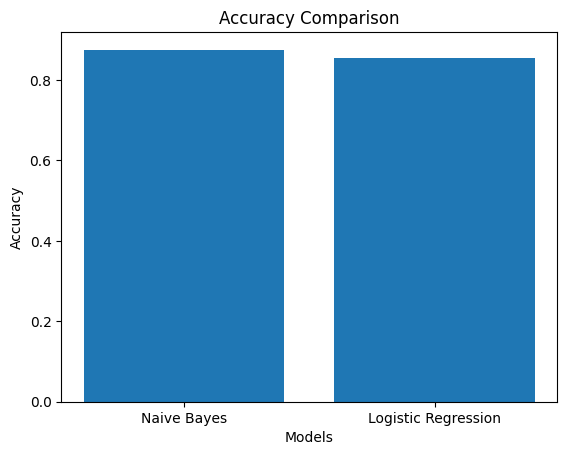

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Step 1: Load dataset
data = pd.read_excel("student_performance.xlsx")

X = data[['Hours_Studied','Attendance','Assignments_Score']]
y = data['Result']

# Step 2: Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42
)

# ---------------------------
# Naive Bayes Model
# ---------------------------
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

print("----- Naive Bayes Results -----")
print("Accuracy:", accuracy_score(y_test, nb_pred))

print("\nClassification Report:")
print(classification_report(y_test, nb_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, nb_pred))


# ---------------------------
# Logistic Regression Model
# ---------------------------
lr_model = LogisticRegression(max_iter=200)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("\n\n----- Logistic Regression Results -----")
print("Accuracy:", accuracy_score(y_test, lr_pred))

print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, lr_pred))


# ---------------------------
# Accuracy Comparison Graph
# ---------------------------
nb_accuracy = accuracy_score(y_test, nb_pred)
lr_accuracy = accuracy_score(y_test, lr_pred)

models = ["Naive Bayes", "Logistic Regression"]
accuracy = [nb_accuracy, lr_accuracy]

plt.bar(models, accuracy)
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Models")
plt.show()